In [134]:
import pandas as pd
from pybaseball import standings

all_divisions = standings(2026)
all_divisions

[                  Tm   W   L  W-L%    GB
 1     Tampa Bay Rays  98  64  .605    --
 2   New York Yankees  93  68  .578   4.5
 3     Boston Red Sox  87  75  .537  11.0
 4  Baltimore Orioles  79  82  .491  18.5
 5  Toronto Blue Jays  79  83  .488  19.0,
                     Tm   W   L  W-L%    GB
 1  Cleveland Guardians  85  77  .525    --
 2    Chicago White Sox  84  78  .519   1.0
 3      Minnesota Twins  77  85  .475   8.0
 4       Detroit Tigers  76  86  .469   9.0
 5   Kansas City Royals  69  93  .426  16.0,
                    Tm   W    L  W-L%    GB
 1      Houston Astros  81   81  .500    --
 2       Texas Rangers  80   82  .494   1.0
 3    Seattle Mariners  76   86  .469   5.0
 4           Athletics  64   98  .395  17.0
 5  Los Angeles Angels  62  100  .383  19.0,
                       Tm   W   L  W-L%    GB
 1         Atlanta Braves  94  68  .580    --
 2  Philadelphia Phillies  88  74  .543   6.0
 3          Miami Marlins  80  82  .494  14.0
 4   Washington Nationals  77  85

In [135]:
nl_central = all_divisions[4]
nl_west = all_divisions[5]

nl_central

,Tm,W,L,W-L%,GB
1,Milwaukee Brewers,103,59,.636,--
2,Chicago Cubs,89,73,.549,14.0
3,Pittsburgh Pirates,82,80,.506,21.0
4,St. Louis Cardinals,77,85,.475,26.0
5,Cincinnati Reds,75,87,.463,28.0


In [136]:
both_divisions = pd.concat([nl_central, nl_west])

nlcs_teams = both_divisions[both_divisions["Tm"].isin(["Milwaukee Brewers", "Los Angeles Dodgers"])]

nlcs_teams

,Tm,W,L,W-L%,GB
1,Milwaukee Brewers,103,59,.636,--
1,Los Angeles Dodgers,100,62,.617,--


In [137]:
from pybaseball import schedule_and_record

mil_games = schedule_and_record(2026, "MIL")
lad_games = schedule_and_record(2026, "LAD")

mil_games.head()

http://www.baseball-reference.com/teams/MIL/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/LAD/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


,Date,Tm,Home_Away,Opp,W/L,R,RA,Inn,W-L,Rank,GB,Win,Loss,Save,Time,D/N,Attendance,cLI,Streak,Orig. Scheduled
1,"Thursday, Mar 26",MIL,Home,CHW,W,14.0,2.0,9.0,1-0,1.0,Tied,Misiorowski,Smith,None,3:06,D,43001.0,.86,1.0,None
2,"Saturday, Mar 28",MIL,Home,CHW,W,6.0,1.0,9.0,2-0,1.0,Tied,Ashby,Burke,None,3:01,N,36030.0,.95,2.0,None
3,"Sunday, Mar 29",MIL,Home,CHW,W,9.0,7.0,9.0,3-0,1.0,up 1.0,Woodford,Domínguez,Megill,3:07,D,32737.0,1.35,3.0,None
4,"Monday, Mar 30",MIL,Home,TBR,L,2.0,3.0,9.0,3-1,1.0,Tied,Cleavinger,Megill,Kelly,2:33,N,20022.0,.67,-1.0,None
5,"Tuesday, Mar 31",MIL,Home,TBR,W,6.0,2.0,9.0,4-1,1.0,up 1.0,Woodruff,McClanahan,None,2:33,N,20010.0,.98,1.0,None


In [138]:
  # Sanity check: each team should have 162 games
print("Brewers games:", len(mil_games))
print("Dodgers games:", len(lad_games))

  # Run differential = total runs scored - total runs allowed
mil_rd = mil_games["R"].sum() - mil_games["RA"].sum()
lad_rd = lad_games["R"].sum() - lad_games["RA"].sum()

print("Brewers run differential:", mil_rd)
print("Dodgers run differential:", lad_rd)

Brewers games: 168
Dodgers games: 168
Brewers run differential: 214.0
Dodgers run differential: 201.0


In [139]:
  # What kinds of results are in the W/L column?
print(mil_games["W/L"].value_counts(dropna=False))

  # Look at the last 10 rows of the season
mil_games.tail(10)

W/L
W       97
L       55
W-wo     6
None     6
L-wo     4
Name: count, dtype: int64


,Date,Tm,Home_Away,Opp,W/L,R,RA,Inn,W-L,Rank,GB,Win,Loss,Save,Time,D/N,Attendance,cLI,Streak,Orig. Scheduled
159,"Thursday, Sep 24",MIL,@,PHI,W,5.0,1.0,9.0,100-59,1.0,up12.0,Romero,Alvarado,Senzatela,2:49,N,37177.0,.00,2.0,None
160,"Friday, Sep 25",MIL,Home,STL,W,8.0,4.0,9.0,101-59,1.0,up13.5,Uribe,Gastelum,None,2:54,N,42793.0,.00,3.0,None
161,"Saturday, Sep 26",MIL,Home,STL,W,3.0,2.0,9.0,102-59,1.0,up14.0,Harrison,Mathews,Ashby,2:33,N,42900.0,.41,4.0,None
162,"Sunday, Sep 27",MIL,Home,STL,W,6.0,4.0,9.0,103-59,1.0,up14.0,Misiorowski,Pallante,Drohan,2:24,D,43556.0,.76,5.0,None
163,"Sunday, Oct 11",MIL,Home,LAD,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None
164,"Monday, Oct 12",MIL,Home,LAD,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None
165,"Wednesday, Oct 14",MIL,@,LAD,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None
166,"Thursday, Oct 15",MIL,@,LAD,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None
167,"Friday, Oct 16",MIL,@,LAD,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None
168,"Sunday, Oct 18",MIL,Home,LAD,None,NaN,NaN,NaN,None,NaN,None,None,None,None,None,None,NaN,None,NaN,None


In [140]:
  # First 162 rows = regular season, the rest = postseason
mil_regular = mil_games.iloc[:162]
mil_post = mil_games.iloc[162:]

lad_regular = lad_games.iloc[:162]
lad_post = lad_games.iloc[162:]

  # Sanity check: the running record on the last regular season game
  # should match the final standings (Brewers 103-59, Dodgers 100-62)
print("Brewers final record in data:", mil_regular["W-L"].iloc[-1])
print("Dodgers final record in data:", lad_regular["W-L"].iloc[-1])

  # Recalculate run differential with regular season only
mil_rd = mil_regular["R"].sum() - mil_regular["RA"].sum()
lad_rd = lad_regular["R"].sum() - lad_regular["RA"].sum()

print("Brewers run differential:", mil_rd)
print("Dodgers run differential:", lad_rd)

Brewers final record in data: 103-59
Dodgers final record in data: 100-62
Brewers run differential: 214.0
Dodgers run differential: 201.0


In [141]:
  # Keep only regular season Brewers games where the opponent was the Dodgers
mil_vs_lad = mil_regular[mil_regular["Opp"] == "LAD"]

  # Count wins: W/L values start with "W" (includes walk-offs like "W-wo")
h2h_wins = mil_vs_lad["W/L"].str.startswith("W").sum()
h2h_losses = len(mil_vs_lad) - h2h_wins

  # Run differential in just these games
h2h_rd = mil_vs_lad["R"].sum() - mil_vs_lad["RA"].sum()

print("Brewers vs Dodgers record:", h2h_wins, "-", h2h_losses)
print("Brewers run differential vs Dodgers:", h2h_rd)

mil_vs_lad[["Date", "Home_Away", "W/L", "R", "RA"]]

Brewers vs Dodgers record: 4 - 3
Brewers run differential vs Dodgers: -2.0


,Date,Home_Away,W/L,R,RA
48,"Friday, May 22",Home,W,5.0,1.0
49,"Saturday, May 23",Home,L,3.0,11.0
50,"Sunday, May 24",Home,L,1.0,5.0
122,"Thursday, Aug 13",@,W,5.0,4.0
123,"Friday, Aug 14",@,L,1.0,3.0
124,"Saturday, Aug 15",@,W,4.0,1.0
125,"Sunday, Aug 16",@,W,6.0,2.0


In [142]:
  # Totals for the regular season
mil_rs = mil_regular["R"].sum()
mil_ra = mil_regular["RA"].sum()
lad_rs = lad_regular["R"].sum()
lad_ra = lad_regular["RA"].sum()

  # Build our own comparison table
summary = pd.DataFrame({
      "Team": ["Brewers", "Dodgers"],
      "Record": ["103-59", "100-62"],
      "Runs Scored": [mil_rs, lad_rs],
      "Runs Allowed": [mil_ra, lad_ra],
      "Run Diff": [mil_rs - mil_ra, lad_rs - lad_ra],
  })

  # Per-game averages, rounded to 2 decimals
summary["Scored per Game"] = (summary["Runs Scored"] / 162).round(2)
summary["Allowed per Game"] = (summary["Runs Allowed"] / 162).round(2)

In [143]:
# A reusable "recipe" that summarizes one team's regular season
def season_summary(team_code, year, team_name):
    games = schedule_and_record(year, team_code)
    regular = games.iloc[:162]
    runs_scored = regular["R"].sum()
    runs_allowed = regular["RA"].sum()
    return {
        "Team": team_name,
        "Season": year,
        "Record": regular["W-L"].iloc[-1],
        "Scored per Game": round(runs_scored / 162, 2),
        "Allowed per Game": round(runs_allowed / 162, 2),
        "Run Diff": runs_scored - runs_allowed,
    }

# Use the recipe four times and put the results in one table
comparison = pd.DataFrame([
    season_summary("MIL", 2025, "Brewers"),
    season_summary("MIL", 2026, "Brewers"),
    season_summary("LAD", 2025, "Dodgers"),
    season_summary("LAD", 2026, "Dodgers"),
])

comparison

http://www.baseball-reference.com/teams/MIL/2025-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/MIL/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/LAD/2025-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/LAD/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


,Team,Season,Record,Scored per Game,Allowed per Game,Run Diff
0,Brewers,2025,96-65,4.95,3.90,170.0
1,Brewers,2026,103-59,5.14,3.81,214.0
2,Dodgers,2025,92-69,5.06,4.21,137.0
3,Dodgers,2026,100-62,4.94,3.70,201.0


In [144]:
# A reusable "recipe" that summarizes one team's regular season
def season_summary(team_code, year, team_name):
    games = schedule_and_record(year, team_code)
    played = games[games["R"].notna()]   # keep only games that have a score
    regular = played.iloc[:162]          # first 162 played games = regular season
    runs_scored = regular["R"].sum()
    runs_allowed = regular["RA"].sum()
    return {
        "Team": team_name,
        "Season": year,
        "Record": regular["W-L"].iloc[-1],
        "Scored per Game": round(runs_scored / 162, 2),
        "Allowed per Game": round(runs_allowed / 162, 2),
        "Run Diff": runs_scored - runs_allowed,
    }

# Use the recipe four times and put the results in one table
comparison = pd.DataFrame([
    season_summary("MIL", 2025, "Brewers"),
    season_summary("MIL", 2026, "Brewers"),
    season_summary("LAD", 2025, "Dodgers"),
    season_summary("LAD", 2026, "Dodgers"),
])

comparison

http://www.baseball-reference.com/teams/MIL/2025-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/MIL/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/LAD/2025-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/LAD/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


,Team,Season,Record,Scored per Game,Allowed per Game,Run Diff
0,Brewers,2025,96-65,4.95,3.90,170.0
1,Brewers,2026,103-59,5.14,3.81,214.0
2,Dodgers,2025,92-69,5.06,4.21,137.0
3,Dodgers,2026,100-62,4.94,3.70,201.0


In [145]:
# Investigate the 2025 Brewers data directly
mil_2025 = schedule_and_record(2025, "MIL")
played_2025 = mil_2025[mil_2025["R"].notna()]

print("Total rows:", len(mil_2025))
print("Rows with a score:", len(played_2025))
print(played_2025.iloc[:162]["W/L"].value_counts())

# Show the games around the end of the regular season
played_2025.iloc[156:166][["Date", "Opp", "W/L", "R", "RA", "W-L"]]

http://www.baseball-reference.com/teams/MIL/2025-schedule-scores.shtml
Total rows: 161
Rows with a score: 161
W/L
W       85
L       59
W-wo    11
L-wo     6
Name: count, dtype: int64


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


,Date,Opp,W/L,R,RA,W-L
157,"Monday, Sep 22",SDP,L-wo,4.0,5.0,95-62
158,"Tuesday, Sep 23",SDP,L,0.0,7.0,95-63
159,"Wednesday, Sep 24",SDP,W,3.0,1.0,96-63
160,"Friday, Sep 26",CIN,L,1.0,3.0,96-64
161,"Saturday, Sep 27",CIN,L,4.0,7.0,96-65


In [146]:
# A reusable "recipe" that summarizes one team's regular season.
# missing_game lets us add a verified game the data source left out,
# written as (runs scored, runs allowed).
def season_summary(team_code, year, team_name, missing_game=None):
    games = schedule_and_record(year, team_code)
    regular = games[games["R"].notna()].iloc[:162]
    runs_scored = regular["R"].sum()
    runs_allowed = regular["RA"].sum()
    games_played = len(regular)

    if missing_game is not None:
        runs_scored += missing_game[0]
        runs_allowed += missing_game[1]
        games_played += 1

    return {
        "Team": team_name,
        "Season": year,
        "Games": games_played,
        "Scored per Game": round(runs_scored / games_played, 2),
        "Allowed per Game": round(runs_allowed / games_played, 2),
        "Run Diff": runs_scored - runs_allowed,
    }

# 2025 data from pybaseball is missing each team's Sep 28, 2025 finale.
# Verified scores: Brewers 4, Reds 2 (Baseball Reference box score)
#                  Dodgers 6, Mariners 1 (AP game recap)
comparison = pd.DataFrame([
    season_summary("MIL", 2025, "Brewers", missing_game=(4, 2)),
    season_summary("MIL", 2026, "Brewers"),
    season_summary("LAD", 2025, "Dodgers", missing_game=(6, 1)),
    season_summary("LAD", 2026, "Dodgers"),
])

comparison

http://www.baseball-reference.com/teams/MIL/2025-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/MIL/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/LAD/2025-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/LAD/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.13/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


,Team,Season,Games,Scored per Game,Allowed per Game,Run Diff
0,Brewers,2025,162,4.98,3.91,172.0
1,Brewers,2026,162,5.14,3.81,214.0
2,Dodgers,2025,162,5.09,4.22,142.0
3,Dodgers,2026,162,4.94,3.70,201.0


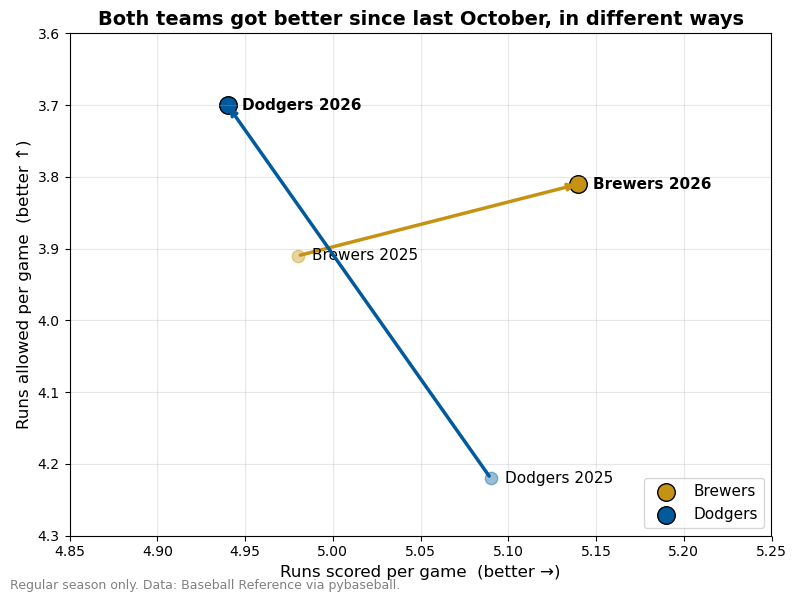

In [147]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

colors = {"Brewers": "#C69214", "Dodgers": "#005A9C"}

for team in ["Brewers", "Dodgers"]:
    rows = comparison[comparison["Team"] == team]
    old = rows[rows["Season"] == 2025].iloc[0]
    new = rows[rows["Season"] == 2026].iloc[0]

    # Arrow from 2025 to 2026
    ax.annotate(
        "",
        xy=(new["Scored per Game"], new["Allowed per Game"]),
        xytext=(old["Scored per Game"], old["Allowed per Game"]),
        arrowprops=dict(arrowstyle="->", color=colors[team], lw=2.5),
    )

    # Dots: faded for 2025, solid for 2026
    ax.scatter(old["Scored per Game"], old["Allowed per Game"],
               color=colors[team], s=80, alpha=0.4)
    ax.scatter(new["Scored per Game"], new["Allowed per Game"],
               color=colors[team], s=160, edgecolor="black", label=team)

    # Labels next to each dot
    ax.text(old["Scored per Game"] + 0.008, old["Allowed per Game"],
            f"{team} 2025", fontsize=11, va="center")
    ax.text(new["Scored per Game"] + 0.008, new["Allowed per Game"],
            f"{team} 2026", fontsize=11, va="center", fontweight="bold")

# Axis ranges, flipped y-axis so "up" means fewer runs allowed
ax.set_xlim(4.85, 5.25)
ax.set_ylim(4.30, 3.60)

ax.set_xlabel("Runs scored per game  (better →)", fontsize=12)
ax.set_ylabel("Runs allowed per game  (better ↑)", fontsize=12)
ax.set_title("Both teams got better since last October, in different ways",
             fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=11)

fig.text(0.01, 0.01, "Regular season only. Data: Baseball Reference via pybaseball.",
         fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("brewers_dodgers_2025_vs_2026.png", dpi=200)
plt.show()

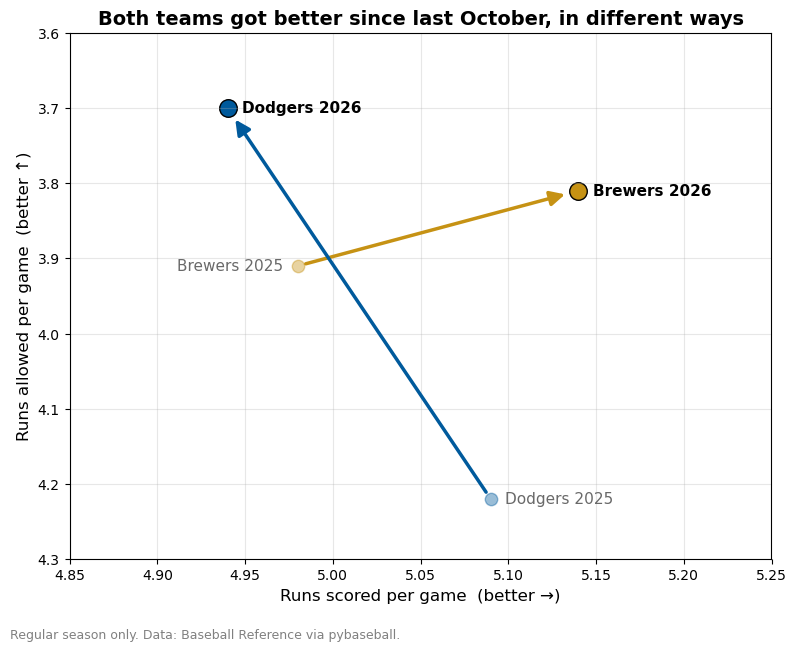

In [148]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6.5))

colors = {"Brewers": "#C69214", "Dodgers": "#005A9C"}

for team in ["Brewers", "Dodgers"]:
    rows = comparison[comparison["Team"] == team]
    old = rows[rows["Season"] == 2025].iloc[0]
    new = rows[rows["Season"] == 2026].iloc[0]

    old_x, old_y = old["Scored per Game"], old["Allowed per Game"]
    new_x, new_y = new["Scored per Game"], new["Allowed per Game"]

    # Bigger, filled arrowhead that stops just short of the dots
    ax.annotate(
        "",
        xy=(new_x, new_y),
        xytext=(old_x, old_y),
        arrowprops=dict(arrowstyle="-|>", color=colors[team], lw=2.5,
                        mutation_scale=22, shrinkA=6, shrinkB=10),
    )

    # Dots: faded for 2025, solid for 2026
    ax.scatter(old_x, old_y, color=colors[team], s=80, alpha=0.4)
    ax.scatter(new_x, new_y, color=colors[team], s=160, edgecolor="black")

    # 2025 label: Brewers goes on the LEFT of its dot to avoid the Dodgers line
    if team == "Brewers":
        ax.text(old_x - 0.008, old_y, "Brewers 2025", fontsize=11,
                va="center", ha="right", color="dimgray")
    else:
        ax.text(old_x + 0.008, old_y, "Dodgers 2025", fontsize=11,
                va="center", ha="left", color="dimgray")

    # 2026 label: bold, to the right of the dot
    ax.text(new_x + 0.008, new_y, f"{team} 2026", fontsize=11,
            va="center", ha="left", fontweight="bold")

# Axis ranges, flipped y-axis so "up" means fewer runs allowed
ax.set_xlim(4.85, 5.25)
ax.set_ylim(4.30, 3.60)

ax.set_xlabel("Runs scored per game  (better →)", fontsize=12)
ax.set_ylabel("Runs allowed per game  (better ↑)", fontsize=12)
ax.set_title("Both teams got better since last October, in different ways",
             fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)

fig.text(0.01, 0.01, "Regular season only. Data: Baseball Reference via pybaseball.",
         fontsize=9, color="gray")

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("brewers_dodgers_2025_vs_2026.png", dpi=200)
plt.show()

In [149]:
# 1. Pythagorean expectation: estimated "true" win % from runs scored and allowed
#    1.83 is the standard exponent baseball analysts use
def pythag(runs_scored, runs_allowed):
    return runs_scored**1.83 / (runs_scored**1.83 + runs_allowed**1.83)

mil_strength = pythag(mil_rs, mil_ra)
lad_strength = pythag(lad_rs, lad_ra)

print("Brewers Pythagorean win %:", round(mil_strength, 3))
print("Dodgers Pythagorean win %:", round(lad_strength, 3))

# 2. Log5: chance team A beats team B in one game on a neutral field
def log5(a, b):
    return (a - a * b) / (a + b - 2 * a * b)

mil_neutral = log5(mil_strength, lad_strength)

# Home field advantage: about +4 percentage points for the home team
home_edge = 0.04
mil_win_at_home = mil_neutral + home_edge
mil_win_on_road = mil_neutral - home_edge

print("Brewers win chance, neutral field:", round(mil_neutral, 3))
print("Brewers win chance, at home:", round(mil_win_at_home, 3))
print("Brewers win chance, in LA:", round(mil_win_on_road, 3))

Brewers Pythagorean win %: 0.633
Dodgers Pythagorean win %: 0.629
Brewers win chance, neutral field: 0.504
Brewers win chance, at home: 0.544
Brewers win chance, in LA: 0.464


In [150]:
import random

# 1. Pythagorean expectation: estimated "true" win % from runs scored and allowed
def pythag(runs_scored, runs_allowed):
    return runs_scored**1.83 / (runs_scored**1.83 + runs_allowed**1.83)

# 2. Log5: chance team A beats team B in one game on a neutral field
def log5(a, b):
    return (a - a * b) / (a + b - 2 * a * b)

mil_neutral = log5(pythag(mil_rs, mil_ra), pythag(lad_rs, lad_ra))
home_edge = 0.04   # home teams win roughly 54% of MLB games

# 3. Simulate the NLCS 100,000 times (2-3-2 format, Brewers have home field)
brewers_home = [True, True, False, False, False, True, True]
results = {}
random.seed(42)   # makes the results repeatable

for _ in range(100000):
    mil_wins, lad_wins = 0, 0
    for is_home in brewers_home:
        p = mil_neutral + home_edge if is_home else mil_neutral - home_edge
        if random.random() < p:
            mil_wins += 1
        else:
            lad_wins += 1
        if mil_wins == 4 or lad_wins == 4:
            break
    winner = "Brewers" if mil_wins == 4 else "Dodgers"
    key = (winner, mil_wins + lad_wins)
    results[key] = results.get(key, 0) + 1

sim = pd.Series(results).sort_index() / 1000   # convert counts to percentages
print(sim.round(1))
print("Brewers win series:", round(sim["Brewers"].sum(), 1), "%")
print("Dodgers win series:", round(sim["Dodgers"].sum(), 1), "%")

Brewers  4     6.3
         5    11.9
         6    16.7
         7    17.1
Dodgers  4     6.0
         5    13.0
         6    14.7
         7    14.3
dtype: float64
Brewers win series: 51.9 %
Dodgers win series: 48.1 %


Brewers win series: 51.9 %
Dodgers win series: 48.1 %


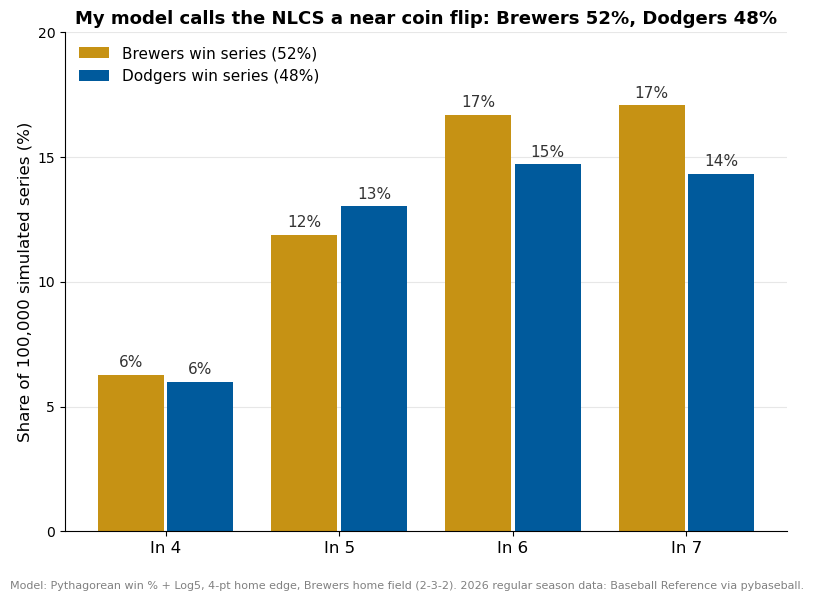

In [151]:
import random

# ---------- MODEL ----------
def pythag(runs_scored, runs_allowed):
    return runs_scored**1.83 / (runs_scored**1.83 + runs_allowed**1.83)

def log5(a, b):
    return (a - a * b) / (a + b - 2 * a * b)

mil_neutral = log5(pythag(mil_rs, mil_ra), pythag(lad_rs, lad_ra))
home_edge = 0.04

brewers_home = [True, True, False, False, False, True, True]
results = {}
random.seed(42)

for _ in range(100000):
    mil_wins, lad_wins = 0, 0
    for is_home in brewers_home:
        p = mil_neutral + home_edge if is_home else mil_neutral - home_edge
        if random.random() < p:
            mil_wins += 1
        else:
            lad_wins += 1
        if mil_wins == 4 or lad_wins == 4:
            break
    winner = "Brewers" if mil_wins == 4 else "Dodgers"
    key = (winner, mil_wins + lad_wins)
    results[key] = results.get(key, 0) + 1

sim = pd.Series(results).sort_index() / 1000
print("Brewers win series:", round(sim["Brewers"].sum(), 1), "%")
print("Dodgers win series:", round(sim["Dodgers"].sum(), 1), "%")

# ---------- CHART ----------
colors = {"Brewers": "#C69214", "Dodgers": "#005A9C"}
lengths = [4, 5, 6, 7]
bar_width = 0.38

fig, ax = plt.subplots(figsize=(8, 6))

for i, team in enumerate(["Brewers", "Dodgers"]):
    values = [sim.get((team, g), 0) for g in lengths]
    x_positions = [g + (i - 0.5) * (bar_width + 0.02) for g in lengths]
    ax.bar(x_positions, values, width=bar_width, color=colors[team],
           label=f"{team} win series ({sim[team].sum():.0f}%)")
    for x, v in zip(x_positions, values):
        ax.text(x, v + 0.3, f"{v:.0f}%", ha="center", fontsize=11, color="#333333")

ax.set_xticks(lengths)
ax.set_xticklabels([f"In {g}" for g in lengths], fontsize=12)
ax.set_ylabel("Share of 100,000 simulated series (%)", fontsize=12)
ax.set_ylim(0, 20)
ax.set_yticks([0, 5, 10, 15, 20])
ax.set_title(f"My model calls the NLCS a near coin flip: "
             f"Brewers {sim['Brewers'].sum():.0f}%, Dodgers {sim['Dodgers'].sum():.0f}%",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.legend(loc="upper left", fontsize=11, frameon=False)

fig.text(0.01, 0.01,
         "Model: Pythagorean win % + Log5, 4-pt home edge, Brewers home field (2-3-2). "
         "2026 regular season data: Baseball Reference via pybaseball.",
         fontsize=8, color="gray")

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("nlcs_series_simulation.png", dpi=200)
plt.show()

In [152]:
from pybaseball import pitching_stats_bref

pitchers = pitching_stats_bref(2026)

candidates = ["Misiorowski", "Henderson", "Dustin May", "Gasser", "Drohan",
              "Yamamoto", "Skubal", "Glasnow", "Snell"]
starters = pitchers[pitchers["Name"].str.contains("|".join(candidates))]
starters[["Name", "Tm", "GS", "IP", "ERA"]]

,Name,Tm,GS,IP,ERA
194,Shane Drohan,Milwaukee,19,124.2,4.19
262,Robert Gasser,Milwaukee,21,113.1,3.81
275,Tyler Glasnow,Los Angeles,14,78.2,3.43
317,Logan Henderson,Milwaukee,19,103.1,2.44
495,Dustin May,"Milwaukee,St. Louis",32,148.2,4.72
530,Jacob Misiorowski,Milwaukee,31,178.2,1.86
742,Tarik Skubal,"Detroit,Los Angeles",27,164.2,2.68
750,Blake Snell,Los Angeles,10,46.1,1.94
751,Robby Snelling,Miami,1,5.0,5.40
890,Yoshinobu Yamamoto,Los Angeles,29,192.0,2.48


In [153]:
import random

def pythag(runs_scored, runs_allowed):
    return runs_scored**1.83 / (runs_scored**1.83 + runs_allowed**1.83)

def log5(a, b):
    return (a - a * b) / (a + b - 2 * a * b)

def get_era(name):
    row = starters[starters["Name"].str.contains(name)]
    return float(row["ERA"].iloc[0])

mil_rs_g, mil_ra_g = mil_rs / 162, mil_ra / 162
lad_rs_g, lad_ra_g = lad_rs / 162, lad_ra / 162

STARTER_SHARE = 0.6
home_edge = 0.04

def game_ra(team_ra_g, starter_era):
    return STARTER_SHARE * starter_era * 1.08 + (1 - STARTER_SHARE) * team_ra_g

# ---- SCENARIO: change to "Drohan" to test Scenario B ----
brewers_game4 = "Gasser"

mil_rotation = ["Misiorowski", "Henderson", "Dustin May", brewers_game4,
                "Misiorowski", "Henderson", "Dustin May"]
lad_rotation = ["Skubal", "Blake Snell", "Yamamoto", "Glasnow",
                "Skubal", "Blake Snell", "Yamamoto"]
brewers_home = [True, True, False, False, False, True, True]

game_probs = []
for g in range(7):
    mil_strength = pythag(mil_rs_g, game_ra(mil_ra_g, get_era(mil_rotation[g])))
    lad_strength = pythag(lad_rs_g, game_ra(lad_ra_g, get_era(lad_rotation[g])))
    p = log5(mil_strength, lad_strength)
    p = p + home_edge if brewers_home[g] else p - home_edge
    game_probs.append(p)

game_table = pd.DataFrame({
    "Game": range(1, 8),
    "Brewers starter": mil_rotation,
    "Dodgers starter": lad_rotation,
    "Where": ["MIL" if h else "LA" for h in brewers_home],
    "Brewers win %": [round(p * 100, 1) for p in game_probs],
})
print("Scenario: Game 4 starter =", brewers_game4)
print(game_table.to_string(index=False))

Scenario: Game 4 starter = Gasser
 Game Brewers starter Dodgers starter Where  Brewers win %
    1     Misiorowski          Skubal   MIL           63.1
    2       Henderson     Blake Snell   MIL           50.0
    3      Dustin May        Yamamoto    LA           30.2
    4          Gasser         Glasnow    LA           44.3
    5     Misiorowski          Skubal    LA           55.1
    6       Henderson     Blake Snell   MIL           50.0
    7      Dustin May        Yamamoto   MIL           38.2


In [154]:
brewers_home = [True, True, False, False, False, True, True]

game_probs = []
for g in range(7):
    mil_strength = pythag(mil_rs_g, game_ra(mil_ra_g, get_era(mil_rotation[g])))
    lad_strength = pythag(lad_rs_g, game_ra(lad_ra_g, get_era(lad_rotation[g])))
    p = log5(mil_strength, lad_strength)
    p = p + home_edge if brewers_home[g] else p - home_edge
    game_probs.append(p)

game_table = pd.DataFrame({
    "Game": range(1, 8),
    "Brewers starter": mil_rotation,
    "Dodgers starter": lad_rotation,
    "Where": ["MIL" if h else "LA" for h in brewers_home],
    "Brewers win %": [round(p * 100, 1) for p in game_probs],
})
print("Scenario: Game 4 starter =", brewers_game4)
print(game_table.to_string(index=False))

Scenario: Game 4 starter = Gasser
 Game Brewers starter Dodgers starter Where  Brewers win %
    1     Misiorowski          Skubal   MIL           63.1
    2       Henderson     Blake Snell   MIL           50.0
    3      Dustin May        Yamamoto    LA           30.2
    4          Gasser         Glasnow    LA           44.3
    5     Misiorowski          Skubal    LA           55.1
    6       Henderson     Blake Snell   MIL           50.0
    7      Dustin May        Yamamoto   MIL           38.2


In [155]:
starters.loc[starters["Name"].str.contains("Misiorowski"), "ERA"] = 1.80   # official MLB.com ERA

In [156]:
starters.loc[starters["Name"].str.contains("Dustin May"), "ERA"] = 4.70

In [157]:
print("ERA the model uses for Misiorowski:", get_era("Misiorowski"))
print(starters[starters["Name"].str.contains("Misiorowski")][["Name", "ERA"]])
print("Game 1 Brewers win %:", round(game_probs[0] * 100, 1))

ERA the model uses for Misiorowski: 1.8
                  Name  ERA
530  Jacob Misiorowski  1.8
Game 1 Brewers win %: 63.1


In [158]:
game_probs = []
for g in range(7):
    mil_strength = pythag(mil_rs_g, game_ra(mil_ra_g, get_era(mil_rotation[g])))
    lad_strength = pythag(lad_rs_g, game_ra(lad_ra_g, get_era(lad_rotation[g])))
    p = log5(mil_strength, lad_strength)
    p = p + home_edge if brewers_home[g] else p - home_edge
    game_probs.append(p)

for g in range(7):
    print("Game", g + 1, mil_rotation[g], "vs", lad_rotation[g], ":", round(game_probs[g] * 100, 1), "%")

Game 1 Misiorowski vs Skubal : 63.8 %
Game 2 Henderson vs Blake Snell : 50.0 %
Game 3 Dustin May vs Yamamoto : 30.3 %
Game 4 Gasser vs Glasnow : 44.3 %
Game 5 Misiorowski vs Skubal : 55.8 %
Game 6 Henderson vs Blake Snell : 50.0 %
Game 7 Dustin May vs Yamamoto : 38.3 %


In [159]:
# Scenario C: Misiorowski starts Game 7 on short rest
mil_rotation_c = ["Misiorowski", "Henderson", "Dustin May", "Gasser",
                  "Misiorowski", "Henderson", "Misiorowski"]
share_c = [0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.4]   # Game 7: ~3-4 innings on short rest

game_probs = []
for g in range(7):
    mil_ra_game = share_c[g] * get_era(mil_rotation_c[g]) * 1.08 + (1 - share_c[g]) * mil_ra_g
    mil_strength = pythag(mil_rs_g, mil_ra_game)
    lad_strength = pythag(lad_rs_g, game_ra(lad_ra_g, get_era(lad_rotation[g])))
    p = log5(mil_strength, lad_strength)
    p = p + home_edge if brewers_home[g] else p - home_edge
    game_probs.append(p)
    print("Game", g + 1, mil_rotation_c[g], "vs", lad_rotation[g], ":", round(p * 100, 1), "%")

Game 1 Misiorowski vs Skubal : 63.8 %
Game 2 Henderson vs Blake Snell : 50.0 %
Game 3 Dustin May vs Yamamoto : 30.3 %
Game 4 Gasser vs Glasnow : 44.3 %
Game 5 Misiorowski vs Skubal : 55.8 %
Game 6 Henderson vs Blake Snell : 50.0 %
Game 7 Misiorowski vs Yamamoto : 56.1 %


In [160]:
import random

def pythag(runs_scored, runs_allowed):
    return runs_scored**1.83 / (runs_scored**1.83 + runs_allowed**1.83)

def log5(a, b):
    return (a - a * b) / (a + b - 2 * a * b)

starters["ERA"] = starters["ERA"].astype(float)   # make sure ERA is a number, not text

# Official MLB.com ERA where Baseball Reference differs
starters.loc[starters["Name"].str.contains("Misiorowski"), "ERA"] = 1.80

def get_era(name):
    row = starters[starters["Name"].str.contains(name)]
    return float(row["ERA"].iloc[0])

mil_rs_g, mil_ra_g = mil_rs / 162, mil_ra / 162
lad_rs_g, lad_ra_g = lad_rs / 162, lad_ra / 162
home_edge = 0.04
brewers_home = [True, True, False, False, False, True, True]

# Probable starters, projected from each team's NLDS rotation
lad_rotation = ["Skubal", "Blake Snell", "Yamamoto", "Glasnow",
                "Skubal", "Blake Snell", "Yamamoto"]

/var/folders/q2/9yy46qdj0psgrc7nfjncqf_40000gn/T/ipykernel_61533/1973347443.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  starters["ERA"] = starters["ERA"].astype(float)   # make sure ERA is a number, not text


In [161]:
def simulate_series(mil_rotation, mil_share, n=100000):
    # Brewers' win chance in each game, based on that day's starters
    game_probs = []
    for g in range(7):
        mil_ra_game = mil_share[g] * get_era(mil_rotation[g]) * 1.08 + (1 - mil_share[g]) * mil_ra_g
        lad_ra_game = 0.6 * get_era(lad_rotation[g]) * 1.08 + 0.4 * lad_ra_g
        p = log5(pythag(mil_rs_g, mil_ra_game), pythag(lad_rs_g, lad_ra_game))
        p = p + home_edge if brewers_home[g] else p - home_edge
        game_probs.append(p)

    # Play the series n times
    results = {}
    random.seed(42)
    for _ in range(n):
        mil_wins, lad_wins = 0, 0
        for g in range(7):
            if random.random() < game_probs[g]:
                mil_wins += 1
            else:
                lad_wins += 1
            if mil_wins == 4 or lad_wins == 4:
                break
        key = ("Brewers" if mil_wins == 4 else "Dodgers", mil_wins + lad_wins)
        results[key] = results.get(key, 0) + 1

    return game_probs, pd.Series(results).sort_index() / (n / 100)

In [162]:
scenarios = {
    "May starts G7": (["Misiorowski", "Henderson", "Dustin May", "Gasser",
                       "Misiorowski", "Henderson", "Dustin May"], [0.6] * 7),
    "Drohan starts G4": (["Misiorowski", "Henderson", "Dustin May", "Drohan",
                          "Misiorowski", "Henderson", "Dustin May"], [0.6] * 7),
    "Miz starts G7 (short rest)": (["Misiorowski", "Henderson", "Dustin May", "Gasser",
                                    "Misiorowski", "Henderson", "Misiorowski"], [0.6] * 6 + [0.4]),
}

rows = []
for name, (rotation, share) in scenarios.items():
    game_probs, sim_result = simulate_series(rotation, share)
    rows.append({
        "Scenario": name,
        "G1 %": round(game_probs[0] * 100, 1),
        "G7 %": round(game_probs[6] * 100, 1),
        "Brewers in 6 %": round(sim_result[("Brewers", 6)], 1),
        "Brewers in 7 %": round(sim_result[("Brewers", 7)], 1),
        "Brewers series %": round(sim_result["Brewers"].sum(), 1),
    })

scenario_table = pd.DataFrame(rows)
print(scenario_table.to_string(index=False))

                  Scenario  G1 %  G7 %  Brewers in 6 %  Brewers in 7 %  Brewers series %
             May starts G7  63.8  38.3            15.7            12.4              44.5
          Drohan starts G4  63.8  38.3            15.4            12.3              43.6
Miz starts G7 (short rest)  63.8  56.1            15.7            18.0              50.1


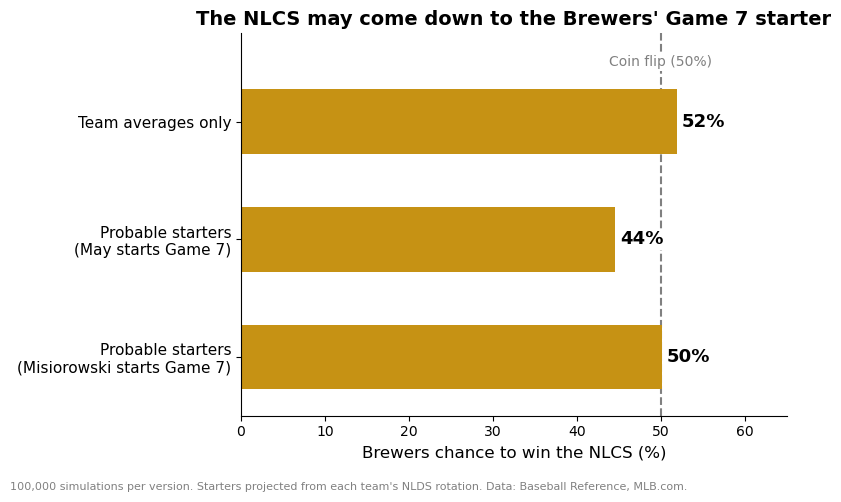

In [163]:
labels = ["Team averages only",
          "Probable starters\n(May starts Game 7)",
          "Probable starters\n(Misiorowski starts Game 7)"]
values = [round(sim["Brewers"].sum(), 1),
          scenario_table.loc[0, "Brewers series %"],
          scenario_table.loc[2, "Brewers series %"]]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, values, color="#C69214", height=0.55)
ax.set_ylim(2.5, -0.75)
ax.axvline(50, color="gray", linestyle="--", linewidth=1.5, zorder=0)
ax.text(50, -0.45, "Coin flip (50%)", color="gray", fontsize=10, ha="center", va="bottom",
        bbox=dict(facecolor="white", edgecolor="none", pad=2))

for bar, v in zip(bars, values):
    ax.text(v + 0.6, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%",
            va="center", fontsize=13, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=1))

ax.set_xlim(0, 65)
ax.set_xlabel("Brewers chance to win the NLCS (%)", fontsize=12)
ax.tick_params(axis="y", labelsize=11)
ax.set_title("The NLCS may come down to the Brewers' Game 7 starter",
             fontsize=14, fontweight="bold")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

fig.text(0.01, 0.01,
         "100,000 simulations per version. Starters projected from each team's NLDS rotation. "
         "Data: Baseball Reference, MLB.com.",
         fontsize=8, color="gray")

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("nlcs_model_versions.png", dpi=200)
plt.show()